# Regression: Prediction Intervals

**Module 6: Correlation Analysis** | Lean Six Sigma Data Analytics

---

## What are Prediction Intervals?

Prediction intervals are used to make predictions about **data that is not in your sample**.

In this video, we will explain:
- When it is useful to calculate a prediction interval
- How to use and interpret such an interval correctly

In [1]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# --- Minitab-style house style -------------------------------------------
import sys
from pathlib import Path as _Path

# minitab_style.py lives in the parent folder of each module directory
sys.path.append(str(_Path.cwd().parent))
import minitab_style as ms

ms.apply_style()

DATA_FILE = '../data/da-lss.xlsx'
xlsx = pd.ExcelFile(DATA_FILE)

print('Ready for prediction interval analysis!')


Ready for prediction interval analysis!


---

## Recap: Steps 1-3 Completed

Let's go back to our broken tea bag and production stop example.

We already performed the first three steps of regression analysis:
1. ✓ Made a fitted line plot
2. ✓ Performed the main analysis (significant, strong predictor)
3. ✓ Performed residual check (assumptions satisfied)

We now move on to the **fourth and final step**: calculating the prediction interval.

In [2]:
# Load data and perform regression
def load_teabags():
    df = pd.read_excel(xlsx, sheet_name='Tea bags', skiprows=7)
    return df.dropna()

teabags = load_teabags()

x = teabags['Stops'].values
y = teabags['Bags'].values

slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
r_squared = r_value**2

# Calculate residuals and their standard deviation
fitted = intercept + slope * x
residuals = y - fitted
residual_std = np.std(residuals, ddof=2)  # Standard deviation of residuals

print('REGRESSION RESULTS (Steps 1-3)')
print('=' * 60)
print()
print(f'Formula: Bags = {intercept:.2f} + {slope:.3f} × Stops')
print(f'P-value: {p_value:.4f} (Significant)')
print(f'R-squared: {r_squared:.1%} (Strong predictor)')
print(f'Residual Std Dev: {residual_std:.2f}')
print()
print('Residuals satisfied assumptions ✓')

REGRESSION RESULTS (Steps 1-3)

Formula: Bags = 6.31 + 1.944 × Stops
P-value: 0.0000 (Significant)
R-squared: 89.0% (Strong predictor)
Residual Std Dev: 1.45

Residuals satisfied assumptions ✓


---

## The Problem with Using Just the Average

Imagine you want to keep the broken tea bags per day **under 15**.

You can look at the fitted line plot and find that 15 defects corresponds to about 5 stops per day.

**However, this is just an average!**

In [3]:
# Show the problem with using just the average
target_bags = 15
stops_for_target = (target_bags - intercept) / slope

print('USING THE AVERAGE')
print('=' * 60)
print()
print(f'Target: Keep defect bags under {target_bags}')
print()
print(f'From fitted line: {target_bags} bags ≈ {stops_for_target:.1f} stops')
print()
print('THE PROBLEM:')
print(f'  With {stops_for_target:.0f} stops per day, you will have {target_bags} defects ON AVERAGE.')
print()
print('  This means:')
print(f'    - Many days with LESS than {target_bags} defects')
print(f'    - But also many days (about half!) with MORE than {target_bags} defects')

USING THE AVERAGE

Target: Keep defect bags under 15

From fitted line: 15 bags ≈ 4.5 stops

THE PROBLEM:
  With 4 stops per day, you will have 15 defects ON AVERAGE.

  This means:
    - Many days with LESS than 15 defects
    - But also many days (about half!) with MORE than 15 defects


---

## The Better Question

We need to define our question differently:

> **What is the maximum number of production stops if we want the number of broken tea bags to be under 15 on MOST of our days?**

Statistically, we will quantify "most days" as **97.5% of the days**.

To find the answer, we must calculate the **prediction interval**.

---

## Calculating the Prediction Interval in Minitab

In Minitab: **Stat > Regression > Fitted Line Plot**
- Response: Bags
- Predictor: Stops
- **Options > Prediction Interval** (check this box)

Note: Minitab automatically works with a **95% level**.

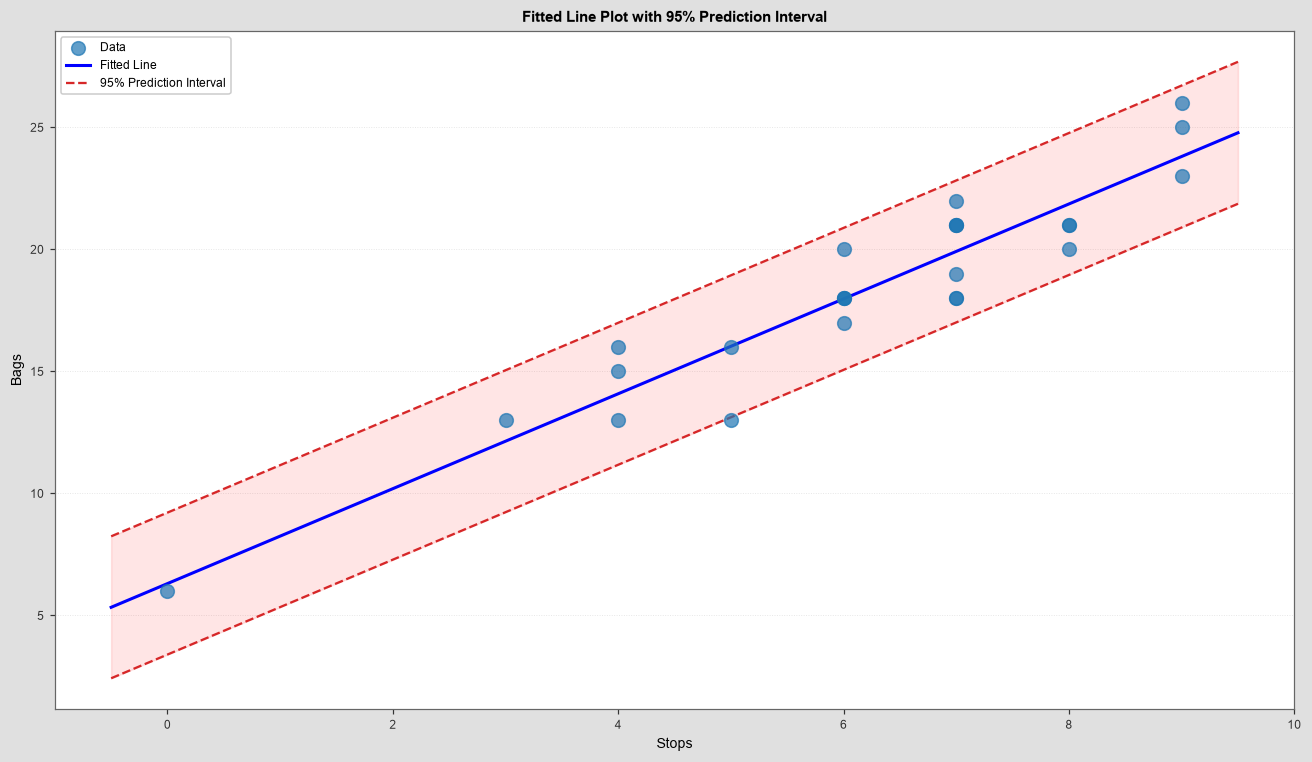

In [4]:
# Calculate and plot prediction interval
# For simple linear regression, prediction interval ≈ fitted ± 2 × residual_std

x_plot = np.linspace(x.min() - 0.5, x.max() + 0.5, 100)
y_fitted = intercept + slope * x_plot

# Simplified prediction interval (approximately 95%)
# In practice, this depends on sample size and x values, but ±2*s is a good approximation
margin = 2 * residual_std
y_upper = y_fitted + margin
y_lower = y_fitted - margin

fig, ax = plt.subplots(figsize=(12, 7))

# Data points
ax.scatter(x, y, s=80, alpha=0.7, zorder=3, label='Data')

# Fitted line
ax.plot(x_plot, y_fitted, 'b-', linewidth=2, label='Fitted Line')

# Prediction interval
ax.plot(x_plot, y_upper, color=ms.RED, linestyle='--', linewidth=1.5, label='95% Prediction Interval')
ax.plot(x_plot, y_lower, color=ms.RED, linestyle='--', linewidth=1.5)
ax.fill_between(x_plot, y_lower, y_upper, alpha=0.1, color='red')

ax.set_xlabel('Stops')
ax.set_ylabel('Bags')
ax.set_title('Fitted Line Plot with 95% Prediction Interval')
ax.legend()

plt.tight_layout()
plt.show()

---

## Understanding the Prediction Interval

The prediction interval is:

$$\text{Prediction Interval} = \text{Fitted Line} \pm 2 \times \text{Standard Deviation of Residuals}$$

What this means:

| Percentage | Location |
|------------|----------|
| 95% | of measurements should be **within** this interval |
| 2.5% | of measurements will be **above** the interval |
| 2.5% | of measurements will be **below** the interval |
| **97.5%** | of measurements will be **below the upper line** |

In [5]:
print('PREDICTION INTERVAL INTERPRETATION')
print('=' * 60)
print()
print(f'Formula: Fitted Value ± 2 × {residual_std:.2f}')
print()
print('What this means:')
print('-' * 40)
print('  95%   of measurements → WITHIN the interval')
print('  2.5%  of measurements → ABOVE the upper line')
print('  2.5%  of measurements → BELOW the lower line')
print()
print('KEY INSIGHT:')
print('  If you repeat measurements frequently,')
print('  97.5% will be BELOW the upper line of the interval.')

PREDICTION INTERVAL INTERPRETATION

Formula: Fitted Value ± 2 × 1.45

What this means:
----------------------------------------
  95%   of measurements → WITHIN the interval
  2.5%  of measurements → ABOVE the upper line
  2.5%  of measurements → BELOW the lower line

KEY INSIGHT:
  If you repeat measurements frequently,
  97.5% will be BELOW the upper line of the interval.


---

## Reading the Prediction Interval Graph

In Minitab, you can use **crosshairs** to navigate the graph:
- Right-click in the graph area → Crosshairs
- Move to your target Y value
- Read the corresponding X value from the upper prediction line

Let's find: For a maximum of 15 defect bags (on 97.5% of days), how many stops can we have?

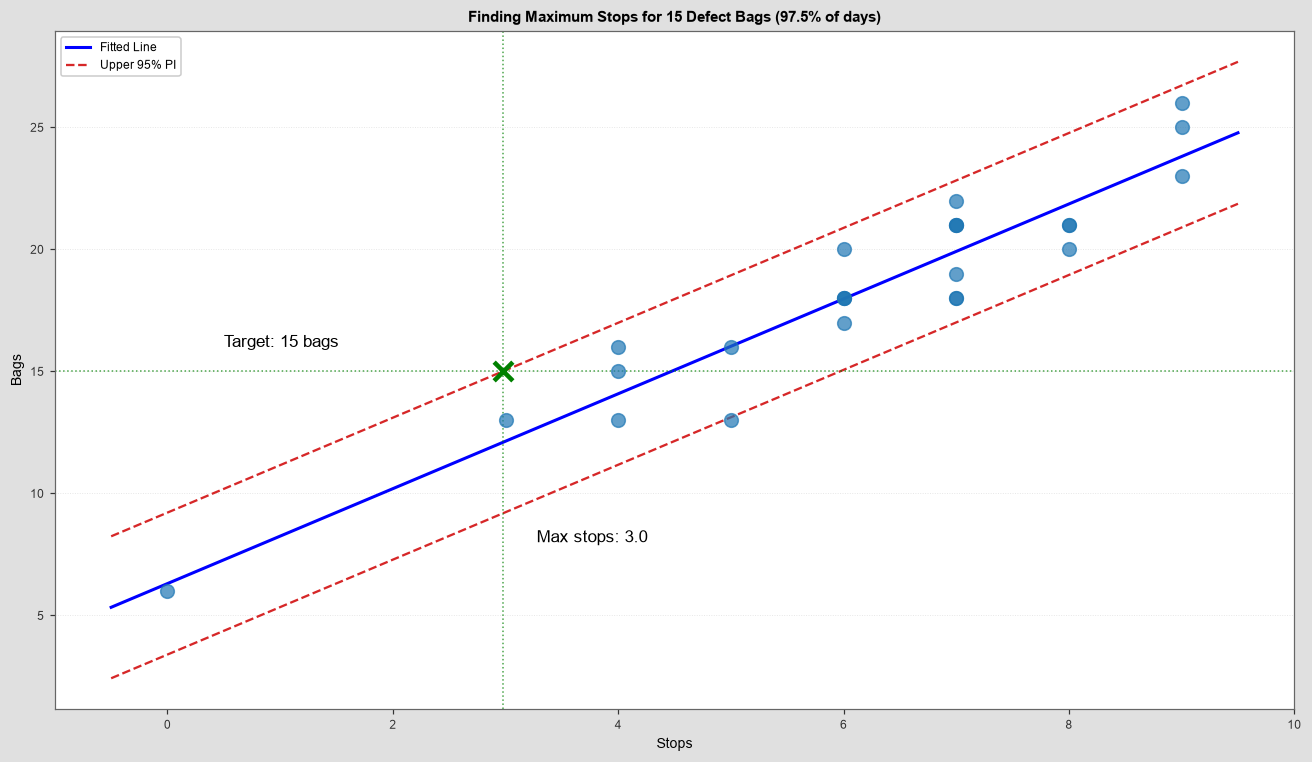

ANSWER: For a maximum of 15 bags on 97.5% of days,
        we need at most 3 stops per day (actually just under 3.0).


In [6]:
# Find the maximum stops for target bags using the UPPER prediction line
target_bags = 15

# Upper line: y = intercept + slope*x + 2*residual_std
# Solve for x: x = (y - intercept - 2*residual_std) / slope
max_stops = (target_bags - intercept - 2*residual_std) / slope

# Visualize this
fig, ax = plt.subplots(figsize=(12, 7))

# Data and lines
ax.scatter(x, y, s=80, alpha=0.7, zorder=3)
ax.plot(x_plot, y_fitted, 'b-', linewidth=2, label='Fitted Line')
ax.plot(x_plot, y_upper, color=ms.RED, linestyle='--', linewidth=1.5, label='Upper 95% PI')
ax.plot(x_plot, y_lower, color=ms.RED, linestyle='--', linewidth=1.5)

# Add crosshairs at target
ax.axhline(target_bags, color='green', linestyle=':', alpha=0.7)
ax.axvline(max_stops, color='green', linestyle=':', alpha=0.7)
ax.scatter([max_stops], [target_bags], s=150, color='green', zorder=5, marker='x', linewidths=3)

# Annotate
ax.annotate(f'Target: {target_bags} bags', xy=(x.min(), target_bags), 
            xytext=(x.min() + 0.5, target_bags + 1), fontsize=11)
ax.annotate(f'Max stops: {max_stops:.1f}', xy=(max_stops, y.min()), 
            xytext=(max_stops + 0.3, y.min() + 2), fontsize=11)

ax.set_xlabel('Stops')
ax.set_ylabel('Bags')
ax.set_title(f'Finding Maximum Stops for {target_bags} Defect Bags (97.5% of days)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'ANSWER: For a maximum of {target_bags} bags on 97.5% of days,')
print(f'        we need at most {max_stops:.0f} stops per day (actually just under {max_stops:.1f}).')

---

## Verifying with the Formula

We can also calculate this using the formula directly.

In [7]:
print('VERIFICATION WITH FORMULA')
print('=' * 60)
print()
print(f'If we have 3 stops:')
print()
stops_check = 3
mean_bags = intercept + slope * stops_check
print(f'  Mean bags = {intercept:.2f} + {slope:.3f} × {stops_check}')
print(f'            = {mean_bags:.1f}')
print()
upper_limit = mean_bags + 2 * residual_std
print(f'  Upper limit = {mean_bags:.1f} + 2 × {residual_std:.2f}')
print(f'              = {mean_bags:.1f} + {2*residual_std:.1f}')
print(f'              = {upper_limit:.1f}')
print()
print(f'With 3 stops, the maximum defect bags (97.5% of days) ≈ {upper_limit:.0f}')
print()
print('CONCLUSION:')
print(f'  To keep defects under 15 on 97.5% of days,')
print(f'  the maximum number of production stops is 3.')

VERIFICATION WITH FORMULA

If we have 3 stops:

  Mean bags = 6.31 + 1.944 × 3
            = 12.1

  Upper limit = 12.1 + 2 × 1.45
              = 12.1 + 2.9
              = 15.0

With 3 stops, the maximum defect bags (97.5% of days) ≈ 15

CONCLUSION:
  To keep defects under 15 on 97.5% of days,
  the maximum number of production stops is 3.


---

## Summary

### Step 4: Prediction Interval

The prediction interval can be used to determine the level of the influence factor which ensures a certain **CTQ performance**.

### How to Use It

| Method | How |
|--------|-----|
| Crosshairs | Navigate graph to find X value on upper prediction line for your target Y |
| Formula | Solve: Target = Fitted + 2 × Residual Std Dev |

### Key Points

- The fitted line gives you the **average** (50% above, 50% below)
- The upper prediction line gives you the **97.5% limit**
- Use the prediction interval when you need to ensure performance on **most days**, not just on average